In [1]:
import polars as pl 
import seaborn as sns 
import matplotlib.pyplot as plt 
from dbconfig import engine 
print('Environment ready!')

Environment ready!


In [2]:
base_table = pl.read_database(
query = """
with match_stats as (

select season, team,
count(distinct id) as matches_played,
sum(is_win) as wins 
from (

select team1 as team,
id, season,
case when winner = team1 then 1 else 0 end as is_win
from matches 

union all 

select team2 as team,
id, season,
case when winner = team2 then 1 else 0 end as is_win
from matches ) as stacked

group by season, team),

delivery_stats as (

select
bowling_team as team,
season,
count(*) as balls_faced,
count(*) filter(where total_runs = 0) as dot_balls,
count(*) filter(where batsman_runs in (4,6)) as boundaries,
sum(total_runs) as runs_scored
from ipl_master_view
where inning in (1,2)
group by team, season)

select m.team,
m.season,
m.matches_played,
round(100.00 * m.wins::numeric / m.matches_played, 2) as win_pct,
round(100.00 * d.dot_balls::numeric / d.balls_faced, 2) as dot_ball_pct,
round(100.00 * d.boundaries::numeric / d.balls_faced, 2) as boundary_pct,
round(runs_scored::numeric / d.balls_faced * 6.00, 2) as run_rate
from match_stats m 
join delivery_stats d on m.team = d.team and m.season = d.season
order by m.team, m.season;""",
connection = engine)

In [3]:
base_table.head(5)

team,season,matches_played,win_pct,dot_ball_pct,boundary_pct,run_rate
str,str,i64,"decimal[38,2]","decimal[38,2]","decimal[38,2]","decimal[38,2]"
"""Chennai Super Kings""","""2007/08""",16,56.25,34.22,16.82,8.08
"""Chennai Super Kings""","""2009""",14,57.14,37.70,14.58,7.39
"""Chennai Super Kings""","""2009/10""",16,56.25,36.90,15.63,7.64
"""Chennai Super Kings""","""2011""",16,68.75,35.81,13.98,7.36
"""Chennai Super Kings""","""2012""",18,55.56,34.85,14.54,7.45


In [4]:
base_table.sort(pl.col('dot_ball_pct'), descending = True).head(5)

team,season,matches_played,win_pct,dot_ball_pct,boundary_pct,run_rate
str,str,i64,"decimal[38,2]","decimal[38,2]","decimal[38,2]","decimal[38,2]"
"""Sunrisers Hyderabad""","""2013""",17,58.82,42.01,13.58,6.89
"""Sunrisers Hyderabad""","""2011""",14,42.86,40.60,15.34,7.30
"""Punjab Kings""","""2009""",14,50.00,40.26,14.45,7.30
"""Rajasthan Royals""","""2009""",13,46.15,39.96,12.18,6.75
"""Kochi Tuskers Kerala""","""2011""",14,42.86,38.79,15.24,7.38


In [5]:
base_table.sort(pl.col('boundary_pct'), descending = True).head(5)

team,season,matches_played,win_pct,dot_ball_pct,boundary_pct,run_rate
str,str,i64,"decimal[38,2]","decimal[38,2]","decimal[38,2]","decimal[38,2]"
"""Sunrisers Hyderabad""","""2024""",16,56.25,29.22,21.76,9.58
"""Delhi Capitals""","""2024""",14,50.00,30.17,21.65,9.54
"""Royal Challengers Bengaluru""","""2024""",15,46.67,30.76,21.21,9.39
"""Gujarat Titans""","""2024""",12,41.67,31.80,20.98,9.34
"""Punjab Kings""","""2023""",14,42.86,31.22,20.97,9.11


In [6]:
plot_table = base_table.with_columns(
        pl.col("win_pct").cast(pl.Float64),
        pl.col("dot_ball_pct").cast(pl.Float64),
        pl.col("boundary_pct").cast(pl.Float64),
        pl.col("run_rate").cast(pl.Float64))

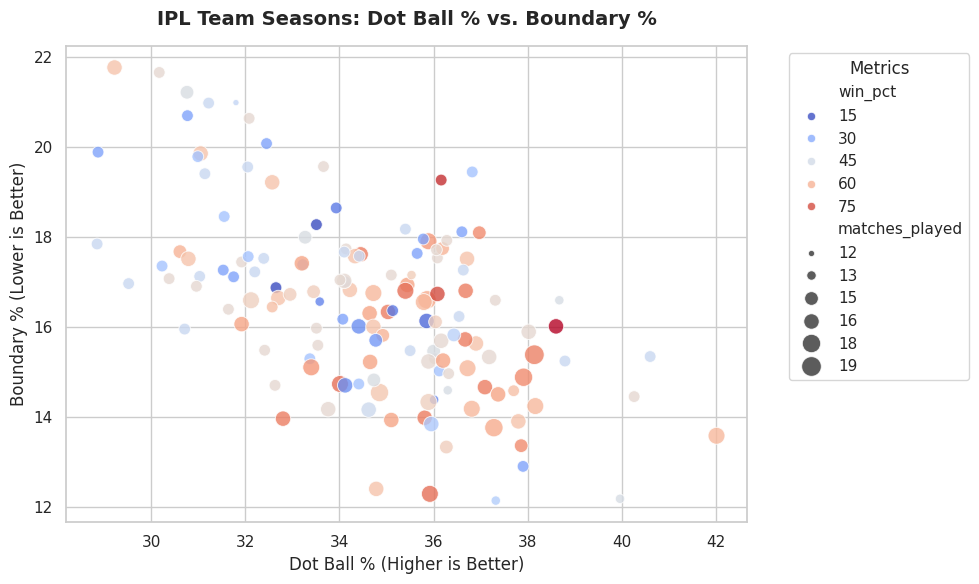

In [7]:
# 1. Set the canvas size (width=10, height=6 inches)
plt.figure(figsize=(10, 6))

# 2. Set the style to make it look premiumsns
sns.set_theme(style="whitegrid")

# 3. Create the scatter plot
sns.scatterplot(
    data=plot_table,
    x="dot_ball_pct",
    y="boundary_pct",
    hue="win_pct",         # Color the dots by win percentage
    palette="coolwarm",    # Cool (blue) for low win %, Warm (red) for high win %
    size="matches_played", # Larger dots for seasons with more games (reduces small-sample noise)
    sizes=(20, 200),       # Minimum and maximum dot sizes
    alpha=0.8              # Make dots slightly transparent to see overlaps
)

# 4. Add clear, professional titles and labels
plt.title("IPL Team Seasons: Dot Ball % vs. Boundary %", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Dot Ball % (Higher is Better)", fontsize=12)
plt.ylabel("Boundary % (Lower is Better)", fontsize=12)

# 5. Place the legend outside the plot so it doesn't block data points
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Metrics")

# 6. Adjust layout to prevent clipping
plt.tight_layout()

plt.savefig('plots/dot_ball_boundary_tradeoff_bowlers_view.png', dpi=300,
  bbox_inches='tight')

# 7. Render the plot
plt.show()


In [8]:
median_dot = plot_table['dot_ball_pct'].median()
median_boundary = plot_table['boundary_pct'].median()
print(f"Median Dot Ball %: {median_dot:.2f}")
print(f"Median Boundary %: {median_boundary:.2f}")

Median Dot Ball %: 34.75
Median Boundary %: 16.57


In [9]:
quadrant_df = plot_table.with_columns(
    pl.when((pl.col("dot_ball_pct") >= median_dot) & (pl.col("boundary_pct")
  >= median_boundary))
        .then(pl.lit("High Dot, High Boundary"))
        .when((pl.col("dot_ball_pct") >= median_dot) & (pl.col("boundary_pct") <
  median_boundary))
        .then(pl.lit("High Dot, Low Boundary"))
        .when((pl.col("dot_ball_pct") < median_dot) & (pl.col("boundary_pct") >=
  median_boundary))
        .then(pl.lit("Low Dot, High Boundary"))
        .otherwise(pl.lit("Low Dot, Low Boundary"))
        .alias("quadrant")
)

In [10]:
quadrant_summary = (
        quadrant_df.group_by('quadrant').agg(
            [pl.len().alias('team_seasons'),
             pl.col('win_pct').mean().round(2).alias('avg_win_pct')])
            .sort('avg_win_pct', descending=True))
quadrant_summary

quadrant,team_seasons,avg_win_pct
str,u32,f64
"""High Dot, High Boundary""",23,53.1
"""High Dot, Low Boundary""",50,52.06
"""Low Dot, Low Boundary""",23,48.32
"""Low Dot, High Boundary""",50,44.63


In [11]:
plot_table.filter(pl.col('dot_ball_pct') > median_dot).sort('win_pct', descending = True).head(5)

team,season,matches_played,win_pct,dot_ball_pct,boundary_pct,run_rate
str,str,i64,f64,f64,f64,f64
"""Rajasthan Royals""","""2007/08""",16,81.25,38.6,16.01,7.59
"""Kolkata Knight Riders""","""2024""",14,78.57,36.16,19.26,8.75
"""Gujarat Titans""","""2022""",16,75.0,36.08,16.73,7.97
"""Kolkata Knight Riders""","""2012""",17,70.59,35.92,12.29,6.98
"""Punjab Kings""","""2014""",17,70.59,35.4,16.8,8.12


In [12]:
plot_table.filter(pl.col('dot_ball_pct') < median_dot).sort('win_pct').head(5)

team,season,matches_played,win_pct,dot_ball_pct,boundary_pct,run_rate
str,str,i64,f64,f64,f64,f64
"""Delhi Capitals""","""2014""",14,14.29,32.65,16.87,8.37
"""Sunrisers Hyderabad""","""2007/08""",14,14.29,33.51,18.27,8.37
"""Punjab Kings""","""2015""",14,21.43,33.93,18.64,8.49
"""Royal Challengers Bengaluru""","""2017""",13,23.08,33.58,16.56,8.11
"""Pune Warriors""","""2012""",16,25.0,34.12,14.7,7.63
